In [1]:
# CELL 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c8cde8",
    "xtick.color":      "#6b7194",
    "ytick.color":      "#6b7194",
    "text.color":       "#c8cde8",
    "grid.color":       "#2e3250",
    "grid.linewidth":   0.6,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#2e3250",
    "font.family":      "monospace",
})

ACCENT = "#7c6af7"
WARM   = "#f97066"
TEAL   = "#34d4a0"
AMBER  = "#fbbf24"
MUTED  = "#6b7194"
COLORS = {"fast": WARM, "balanced": ACCENT, "gentle": TEAL}


In [2]:
# CELL 2 — Load dataset
df = pd.read_csv("/Users/arujatiwary/Desktop/SEM 6/ATML+EC/codes/nsga2_synthetic_dataset.csv")

print(f"Dataset: {len(df):,} rows | {df['solution_id'].nunique()} policies")
print(df.head())

Dataset: 72,000 rows | 60 policies
   solution_id  time_s  current_A       SoC  temperature_K   SoH  voltage_V
0            0       0   1.386470  0.420207     304.991508  0.93   3.547307
1            0       1   1.637465  0.420452     304.983129  0.93   3.561093
2            0       2   1.886302  0.420733     304.974879  0.93   3.574817
3            0       3   1.053187  0.420891     304.966309  0.93   3.530423
4            0       4   1.831087  0.421164     304.958052  0.93   3.572467


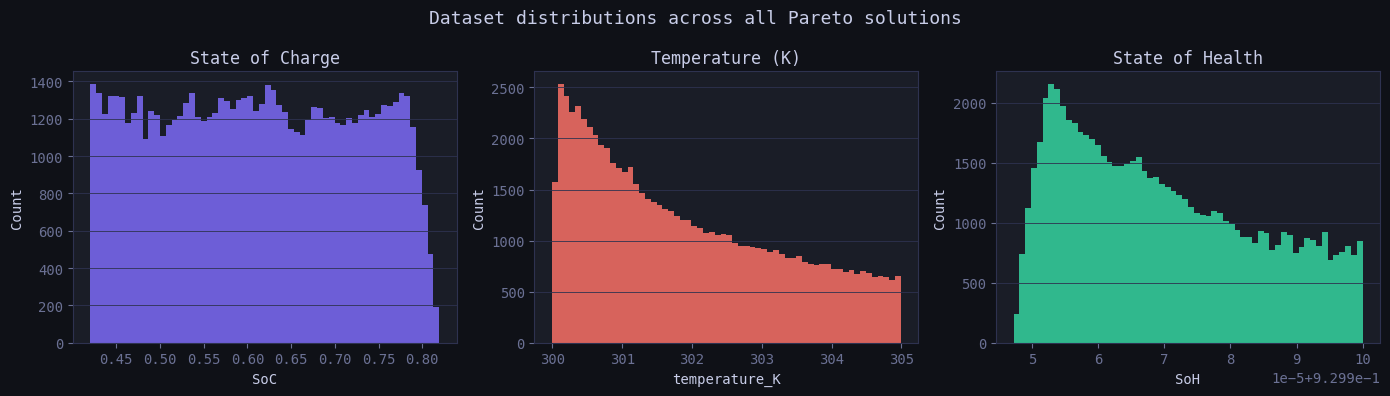

In [3]:
# CELL 3 — Dataset overview plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ["SoC", "temperature_K", "SoH"]
clrs   = [ACCENT, WARM, TEAL]
labels = ["State of Charge", "Temperature (K)", "State of Health"]

for ax, col, clr, lbl in zip(axes, cols, clrs, labels):
    ax.hist(df[col], bins=60, color=clr, alpha=0.85, edgecolor="none")
    ax.set_title(lbl)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.grid(True, axis="y")

fig.suptitle("Dataset distributions across all Pareto solutions", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# CELL 4 — Extract policies
def extract_policies(df):
    policies = {}
    for sid, grp in df.groupby("solution_id"):
        policies[sid] = {
            "current_profile": grp["current_A"].values,
            "soc_traj":        grp["SoC"].values,
            "temp_traj":       grp["temperature_K"].values,
            "soh_traj":        grp["SoH"].values,
        }
    return policies

policies = extract_policies(df)
print(f"Policies loaded: {len(policies)}")

Policies loaded: 60


In [5]:
# CELL 5 — Compute decision metrics
def compute_policy_metrics(policies):
    rows = []
    for pid, data in policies.items():
        soc_gain  = data["soc_traj"][-1]  - data["soc_traj"][0]
        peak_temp = np.max(data["temp_traj"])
        soh_loss  = data["soh_traj"][0]   - data["soh_traj"][-1]
        avg_cur   = np.mean(data["current_profile"])
        rows.append({
            "solution_id": pid,
            "soc_gain":    soc_gain,
            "peak_temp":   peak_temp,
            "soh_loss":    soh_loss,
            "avg_current": avg_cur,
        })
    return pd.DataFrame(rows)

metrics_df = compute_policy_metrics(policies)
print(metrics_df.describe().round(4))

       solution_id  soc_gain  peak_temp  soh_loss  avg_current
count      60.0000   60.0000    60.0000   60.0000      60.0000
mean       29.5000    0.3830   304.9919    0.0001       2.1386
std        17.4642    0.0106     0.0005    0.0000       0.0591
min         0.0000    0.3658   304.9915    0.0000       2.0436
25%        14.7500    0.3725   304.9915    0.0000       2.0810
50%        29.5000    0.3839   304.9915    0.0001       2.1435
75%        44.2500    0.3927   304.9924    0.0001       2.1922
max        59.0000    0.3992   304.9926    0.0001       2.2285


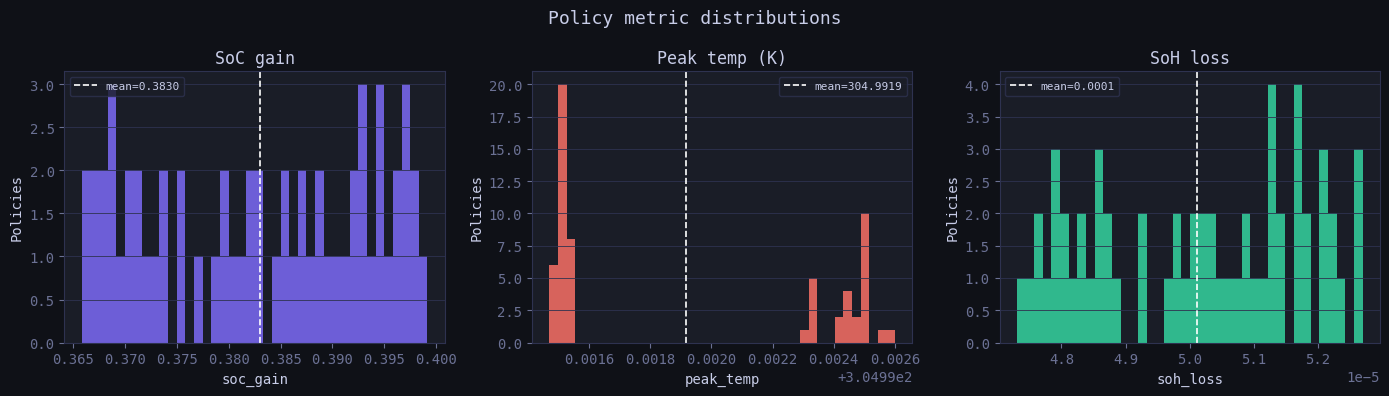

In [6]:
# CELL 6 — Metrics distribution plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ("soc_gain",  "SoC gain",        ACCENT),
    ("peak_temp", "Peak temp (K)",    WARM),
    ("soh_loss",  "SoH loss",         TEAL),
]

for ax, (col, lbl, clr) in zip(axes, pairs):
    ax.hist(metrics_df[col], bins=40, color=clr, alpha=0.85, edgecolor="none")
    ax.axvline(metrics_df[col].mean(), color="white", lw=1.2,
               linestyle="--", label=f"mean={metrics_df[col].mean():.4f}")
    ax.set_title(lbl)
    ax.set_xlabel(col)
    ax.set_ylabel("Policies")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y")

fig.suptitle("Policy metric distributions", fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# CELL 7 — Identify representative policies
def identify_representative_policies(metrics_df):
    fast_idx     = metrics_df["soc_gain"].idxmax()
    gentle_idx   = metrics_df["soh_loss"].idxmin()
    balanced_idx = (metrics_df["soc_gain"] - metrics_df["soc_gain"].median()).abs().idxmin()
    return {
        "fast":     metrics_df.loc[fast_idx,     "solution_id"],
        "balanced": metrics_df.loc[balanced_idx, "solution_id"],
        "gentle":   metrics_df.loc[gentle_idx,   "solution_id"],
    }

policy_choices = identify_representative_policies(metrics_df)
print("Representative policies:")
for name, pid in policy_choices.items():
    row = metrics_df[metrics_df["solution_id"] == pid].iloc[0]
    print(f"  {name:>8}: id={int(pid):3d} | "
          f"soc_gain={row.soc_gain:.4f} | "
          f"peak_temp={row.peak_temp:.2f} K | "
          f"soh_loss={row.soh_loss:.6f}")

Representative policies:
      fast: id=  0 | soc_gain=0.3992 | peak_temp=304.99 K | soh_loss=0.000053
  balanced: id=  6 | soc_gain=0.3848 | peak_temp=304.99 K | soh_loss=0.000051
    gentle: id=  2 | soc_gain=0.3658 | peak_temp=304.99 K | soh_loss=0.000047


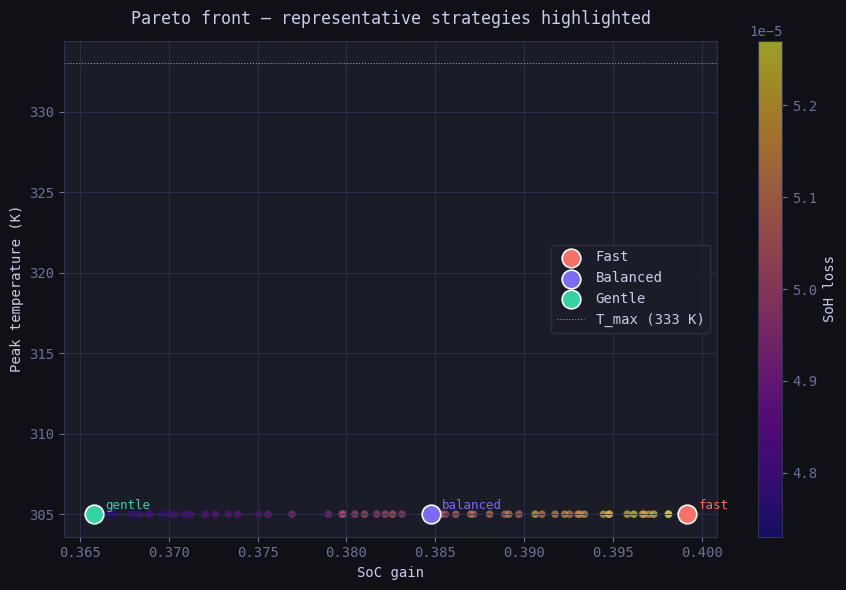

In [8]:
# CELL 8 — Pareto scatter with representatives highlighted
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(metrics_df["soc_gain"], metrics_df["peak_temp"],
                c=metrics_df["soh_loss"], cmap="plasma",
                s=30, alpha=0.6, edgecolors="none", label="_nolegend_")
plt.colorbar(sc, ax=ax, label="SoH loss")

for name, pid in policy_choices.items():
    row = metrics_df[metrics_df["solution_id"] == pid].iloc[0]
    ax.scatter(row.soc_gain, row.peak_temp,
               color=COLORS[name], s=180, zorder=5,
               edgecolors="white", linewidths=1.2,
               label=name.capitalize())
    ax.annotate(name, (row.soc_gain, row.peak_temp),
                textcoords="offset points", xytext=(8, 4),
                fontsize=9, color=COLORS[name])

ax.axhline(333.0, color=WARM, lw=0.8, linestyle=":", label="T_max (333 K)")
ax.set_xlabel("SoC gain")
ax.set_ylabel("Peak temperature (K)")
ax.set_title("Pareto front — representative strategies highlighted", pad=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# CELL 9 — Meta-Agent decision logic
def meta_agent_select(policy_choices, state, mode="auto"):
    """
    Selects charging strategy based on battery state + predictor confidence.

    Priority order:
      1. Confidence gate  — if predictor uncertain, default to gentle
      2. Manual mode      — user override
      3. SoH gate         — degraded battery → gentle
      4. SoC + SoH gate   — low charge + healthy → fast; degraded → balanced
      5. Default          — balanced
    """
    soc        = state["soc"]
    soh        = state["soh"]
    confidence = state.get("confidence", 0.0)

    # 1. Confidence gate
    if confidence > 0.15:
        return policy_choices["gentle"], "predictor uncertainty too high"

    # 2. Manual override
    if mode in ("fast", "balanced", "battery_care"):
        key = "gentle" if mode == "battery_care" else mode
        return policy_choices[key], f"manual mode: {mode}"

    # 3. SoH gate
    if soh < 0.9:
        return policy_choices["gentle"], f"SoH={soh:.2f} below 0.90"

    # 4. SoC + SoH combined
    if soc < 0.4 and soh >= 0.9:
        return policy_choices["fast"], f"low SoC={soc:.2f}, healthy battery"
    if soc < 0.4 and soh < 0.9:
        return policy_choices["balanced"], f"low SoC={soc:.2f}, degraded battery"

    # 5. Default
    return policy_choices["balanced"], "default: balanced"

In [10]:
# CELL 10 — Predictor state (replace with real Predictor output)
transformer_state = {
    "soc":        0.45,
    "soh":        0.95,
    "temp":       300.0,
    "confidence": 0.06,
}

selected_policy, reason = meta_agent_select(
    policy_choices, transformer_state, mode="auto"
)

print(f"Selected policy : {selected_policy}")
print(f"Reason          : {reason}")


Selected policy : 6
Reason          : default: balanced


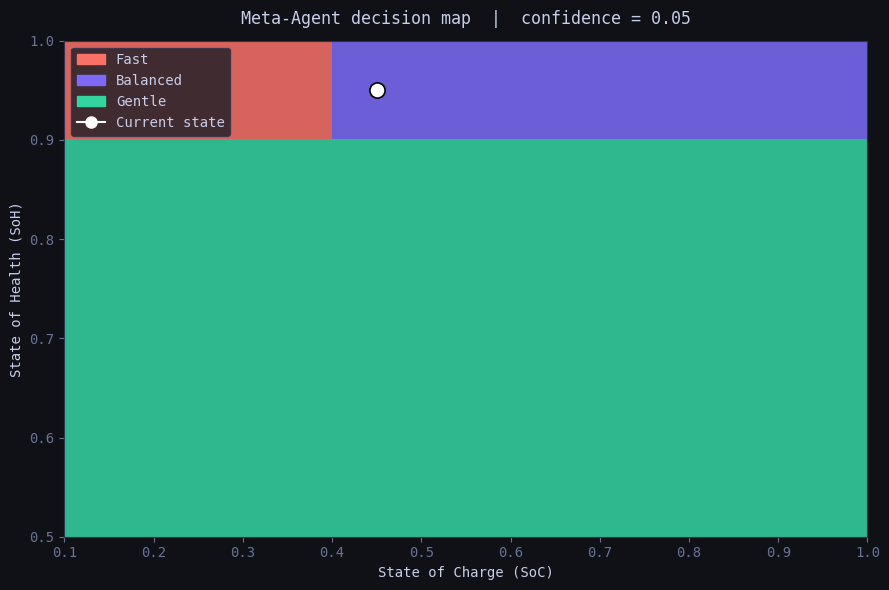

In [11]:
# CELL 11 — Decision logic map (all state combinations)
soc_vals  = np.linspace(0.1, 1.0, 60)
soh_vals  = np.linspace(0.5, 1.0, 60)
decision_grid = np.zeros((len(soh_vals), len(soc_vals)))
label_map = {"fast": 0, "balanced": 1, "gentle": 2}

for i, soh in enumerate(soh_vals):
    for j, soc in enumerate(soc_vals):
        state_tmp = {"soc": soc, "soh": soh, "confidence": 0.05}
        pid, _ = meta_agent_select(policy_choices, state_tmp, mode="auto")
        # map to 0/1/2 based on which representative it matches
        for name, p in policy_choices.items():
            if p == pid:
                decision_grid[i, j] = label_map[name]

from matplotlib.colors import ListedColormap
cmap_dec = ListedColormap([WARM, ACCENT, TEAL])

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(decision_grid, origin="lower", aspect="auto",
               extent=[soc_vals.min(), soc_vals.max(),
                       soh_vals.min(), soh_vals.max()],
               cmap=cmap_dec, vmin=0, vmax=2, alpha=0.85)

patches = [mpatches.Patch(color=WARM,   label="Fast"),
           mpatches.Patch(color=ACCENT, label="Balanced"),
           mpatches.Patch(color=TEAL,   label="Gentle")]
ax.legend(handles=patches, loc="upper left")

# Current state dot
ax.scatter(transformer_state["soc"], transformer_state["soh"],
           color="white", s=120, zorder=5, edgecolors="black",
           linewidths=1.2, label="Current state")

ax.set_xlabel("State of Charge (SoC)")
ax.set_ylabel("State of Health (SoH)")
ax.set_title("Meta-Agent decision map  |  confidence = 0.05", pad=12)
ax.legend(handles=patches + [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor='white', markersize=8, label='Current state')],
          loc="upper left")
ax.grid(False)
plt.tight_layout()
plt.show()


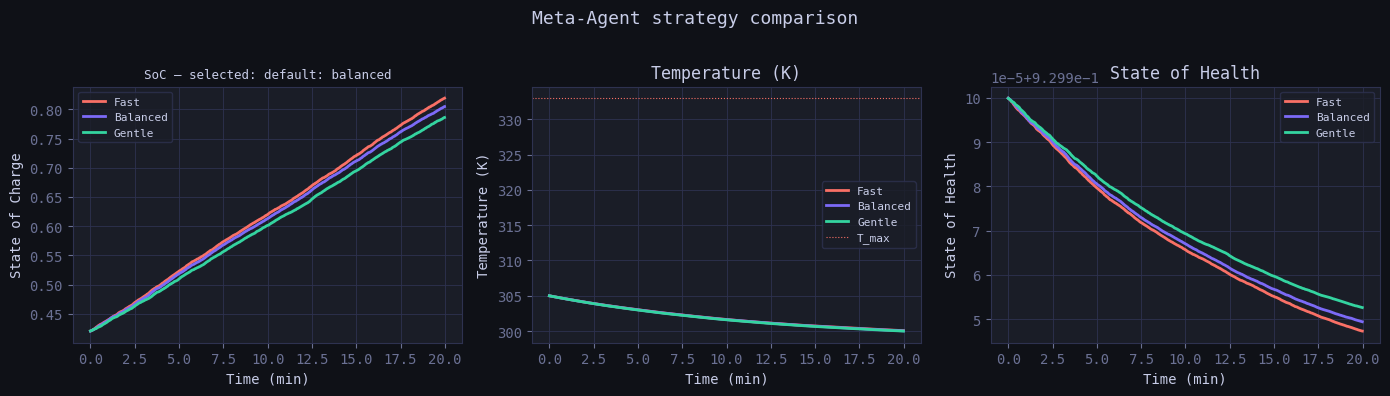

In [12]:
# CELL 12 — SoC trajectories of all three strategies
t_min = np.arange(len(policies[policy_choices["fast"]]["soc_traj"])) / 60

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
metrics_list = [
    ("soc_traj",  "State of Charge",  ""),
    ("temp_traj", "Temperature (K)",  f"T_max = 333 K"),
    ("soh_traj",  "State of Health",  ""),
]

for ax, (key, ylabel, note) in zip(axes, metrics_list):
    for name, pid in policy_choices.items():
        traj = policies[pid][key]
        t    = np.arange(len(traj)) / 60
        ax.plot(t, traj, color=COLORS[name], lw=2.0, label=name.capitalize())
    if note:
        ax.axhline(333.0, color=WARM, lw=0.8, linestyle=":", label="T_max")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True)

# Highlight selected strategy
axes[0].set_title(f"SoC — selected: {reason}", fontsize=9)
fig.suptitle("Meta-Agent strategy comparison", fontsize=13)
plt.tight_layout()
plt.show()

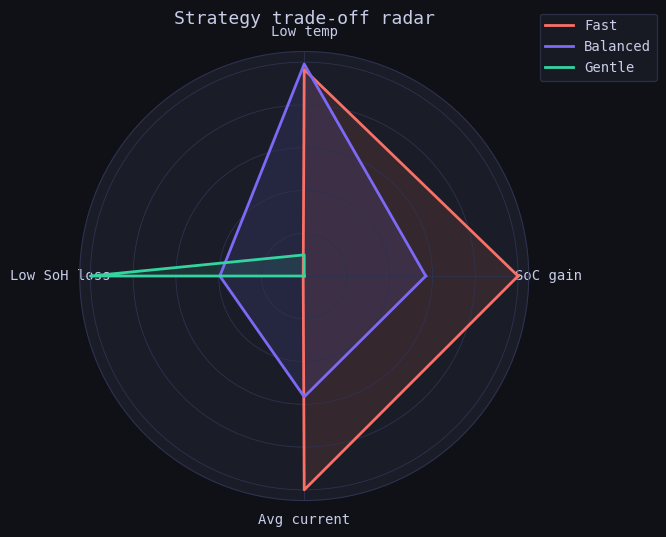

In [13]:
# CELL 13 — Radar chart of strategy trade-offs
from matplotlib.patches import FancyArrowPatch

categories   = ["SoC gain", "Low temp", "Low SoH loss", "Avg current"]
N            = len(categories)
angles       = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles      += angles[:1]

def normalise(val, lo, hi):
    return (val - lo) / (hi - lo + 1e-9)

m = metrics_df
lo = {"soc_gain": m.soc_gain.min(), "peak_temp": m.peak_temp.min(),
      "soh_loss": m.soh_loss.min(), "avg_current": m.avg_current.min()}
hi = {"soc_gain": m.soc_gain.max(), "peak_temp": m.peak_temp.max(),
      "soh_loss": m.soh_loss.max(), "avg_current": m.avg_current.max()}

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor("#1a1d27")

for name, pid in policy_choices.items():
    row = metrics_df[metrics_df["solution_id"] == pid].iloc[0]
    vals = [
        normalise(row.soc_gain,  lo["soc_gain"],  hi["soc_gain"]),
        1 - normalise(row.peak_temp, lo["peak_temp"], hi["peak_temp"]),  # lower = better
        1 - normalise(row.soh_loss,  lo["soh_loss"],  hi["soh_loss"]),   # lower = better
        normalise(row.avg_current, lo["avg_current"], hi["avg_current"]),
    ]
    vals += vals[:1]
    ax.plot(angles, vals, color=COLORS[name], lw=2.0, label=name.capitalize())
    ax.fill(angles, vals, color=COLORS[name], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, color="#c8cde8")
ax.set_yticklabels([])
ax.set_title("Strategy trade-off radar", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.grid(color="#2e3250", linewidth=0.6)
plt.tight_layout()
plt.show()

In [14]:
# CELL 14 — Export selected policy for Kill Agent
selected_profile_data = policies[selected_policy]
print(f"\nPassing policy {selected_policy} to Kill Agent")
print(f"  SoC trajectory length : {len(selected_profile_data['soc_traj'])}")
print(f"  Final SoC             : {selected_profile_data['soc_traj'][-1]:.4f}")
print(f"  Peak temperature      : {max(selected_profile_data['temp_traj']):.2f} K")
print(f"  SoH loss              : {selected_profile_data['soh_traj'][0] - selected_profile_data['soh_traj'][-1]:.6f}")


Passing policy 6 to Kill Agent
  SoC trajectory length : 1200
  Final SoC             : 0.8050
  Peak temperature      : 304.99 K
  SoH loss              : 0.000051
